In [1]:
here::i_am("rna_atac/clustering/02_clustering.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(ArchR))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

set.seed(123)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/code


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
        

In [2]:
args = list()
# MOFAsprintf('%s/results/rna_atac/combined_metadata.txt.gz',io$basedir)
args$metadata = file.path(io$basedir, 'results/rna_atac/combined_metadata.txt.gz')
args$MOFA = file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/mofa/MOFA_factors.txt.gz')
args$MOFA_umap = file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/mofa/MOFA_umap.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')

# outdir
args$outdir_clusters = file.path(io$basedir, 'results/rna_atac/clustering/')
dir.create(args$outdir_clusters, recursive=TRUE, showWarnings =FALSE)

In [3]:
###############
## Load data
###############

# Load meta
meta = fread(args$metadata)

# Load mofa 
mofa = fread(args$MOFA)
umap = fread(args$MOFA_umap)

# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)

In [4]:
seurat = as.Seurat(rna.sce)

Centering and scaling data matrix

PC_ 1 
Positive:  Epcam, Igfbp2, Dnmt3b, Pid1, Ftl1-ps1, Ror1, Emb, Rian, L1td1, Meg3 
	   Alg13, Nrcam, Hs6st2, Tet1, Akap12, Mkrn1, Snhg3, Fgf5, Ppp4r4, Adam23 
	   Gclm, Tgfbr3, B830012L14Rik, Pim2, Dab1, Cldn7, Frmd5, Kcnj3, Tdgf1, 1700019D03Rik 
Negative:  Greb1l, Meis2, Kif26b, Tmem132c, Pcsk5, Fbn2, Pcdh19, Meis1, Lama1, Ifitm1 
	   Foxp1, Aldh1a2, Sdk2, Hoxb3os, Notch1, Maml3, Pax3, Dach1, Lrig3, Tenm4 
	   Maml2, Hmga2, Prkg1, Mdk, Tshz1, Dll1, Cdh2, Mllt3, Ncam1, Kalrn 
PC_ 2 
Positive:  Gpc6, Slit3, Fst, Ppp4r4, Tcf12, Mcc, T, Nrcam, Klhl32, Gria4 
	   Grip1, Adgrl2, Zdbf2, Xkr4, Pbx3, Magi2, Tasp1, Dock11, Rfx3, Pcdh7 
	   Kcnj3, Sema6a, Tgfbr3, Dab1, Dpp10, Dapk1, Pid1, Alcam, Fgf5, Fgf8 
Negative:  Morc1, Lncenc1, Spp1, Dppa5a, Sox2, Zfp42, Lima1, Triml2, Dnah8, Gm49504 
	   Zfp981, Zfp980, Nr5a2, Gm2381, Esrrb, Inpp5d, Fbxo15, Rnf17, 2410141K09Rik, Triml1 
	   Trap1a, Zfp936, AU018091, Zfp978, Sdc4, Zfp600, Lrrc31, Fgf4, Pecam1, Smc1b 


Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 46547
Number of edges: 1432373

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8815
Number of communities: 14
Elapsed time: 18 seconds


Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via the L'Ecuyer-CMRG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
10:26:59 UMAP embedding parameters a = 0.9922 b = 1.112

10:27:03 Read 46547 rows and found 15 numeric columns

10:27:03 Using Annoy for neighbor search, n_neighbors = 30

10:27:04 Building Annoy index with metr

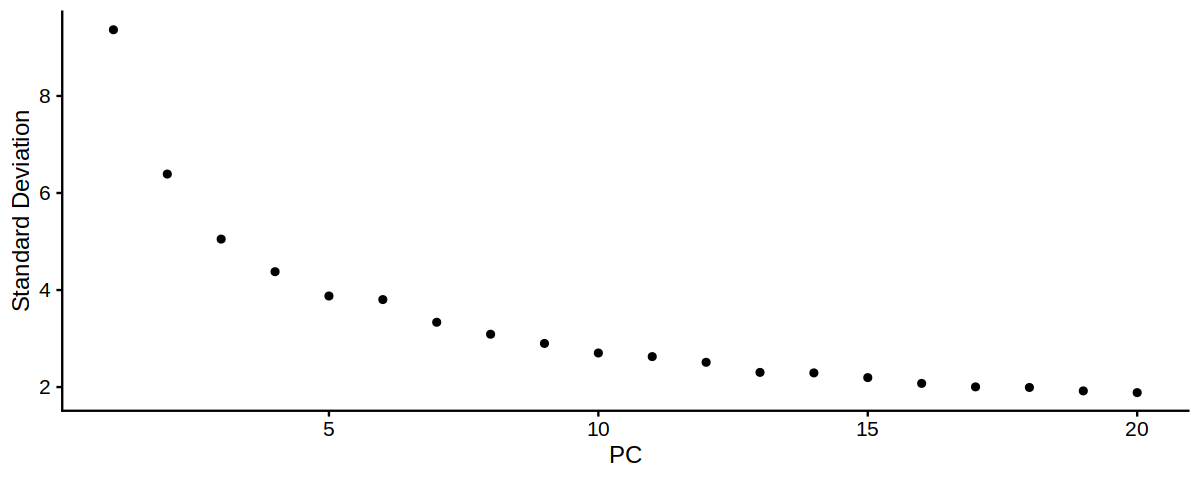

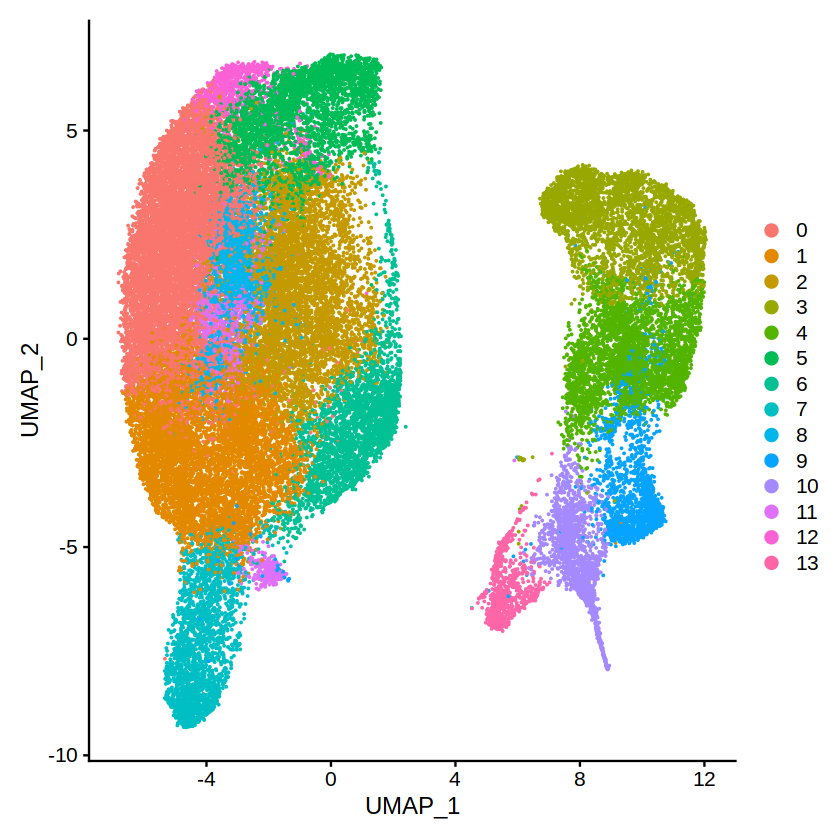

In [5]:
seurat <- NormalizeData(seurat)
seurat <- FindVariableFeatures(seurat, selection.method = "vst", nfeatures = 2000)
seurat <- ScaleData(seurat)
seurat <- RunPCA(seurat, features = VariableFeatures(object = seurat))
options(repr.plot.width=10, repr.plot.height=4)
ElbowPlot(seurat)

seurat <- FindNeighbors(seurat, dims = 1:15)
seurat <- FindClusters(seurat, resolution = 0.5)

options(repr.plot.width=7, repr.plot.height=7)
seurat <- RunUMAP(seurat, dims = 1:15)
DimPlot(seurat, reduction = "umap")

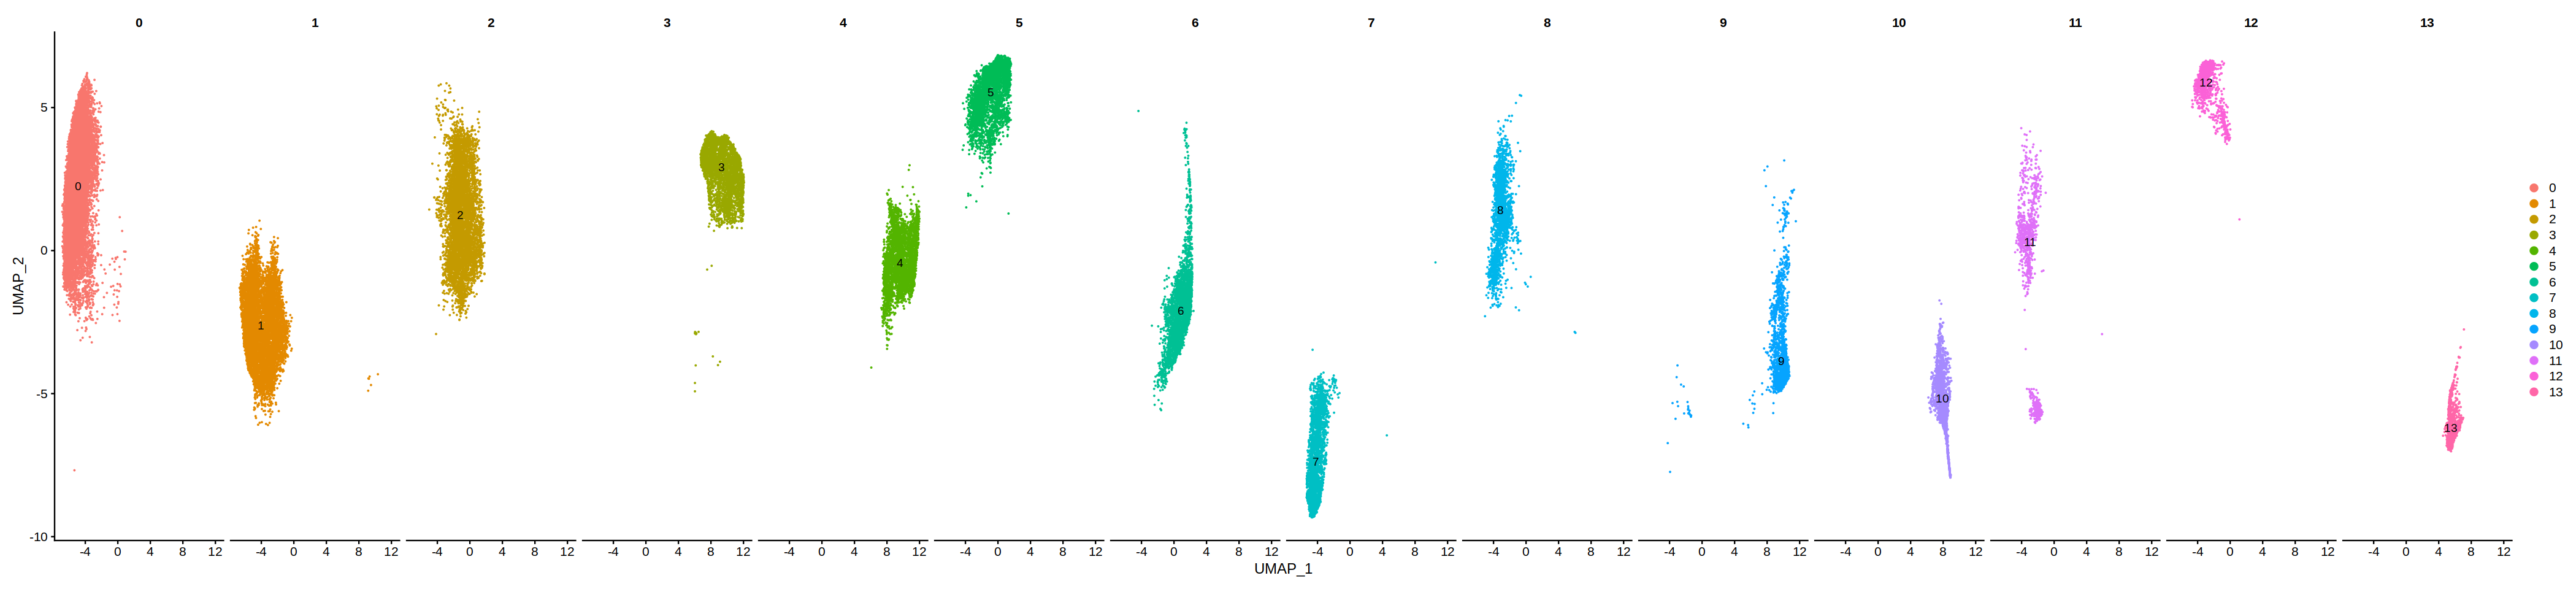

In [7]:
options(repr.plot.width=35, repr.plot.height=8)
DimPlot(seurat, reduction = "umap",  label = TRUE, split.by = 'seurat_clusters') 